# Wild Boar (*Sus scrofa*) Resistance Surface Pipeline — Canton Aargau → Zürich

**Goal:** Build a 25 m permeability/resistance surface for wild boar using GPS telemetry
from Canton Aargau, following Fischer et al. (2024), Clontz et al. (2021), and
Keeley et al. (2016). The calibrated model is then transferred to Canton Zürich.

**Pipeline:**
1. Load & clean telemetry
2. Compute regularised movement metrics
3. Classify steps as *in-patch* or *in-matrix* (hierarchical rule-based classifier)
4. Prepare spatial covariates from SwissTLM3D, DHM25, barriers, and passages
5. Fit integrated Step-Selection Function (iSSF) on *in-matrix* steps
6. Convert iSSF coefficients → resistance surface (Keeley et al. 2016)
7. Transfer resistance surface to Canton Zürich

**Data sources:**
- Telemetry: `WS_Masterfile_final_with_cultures_Aargau.csv`
- SwissTLM3D 2026 (LV95): land cover, water, roads, buildings
- DHM25 (LV03): terrain
- Wildlife passages: `Wildtierpassagen.gdb` → layer `N2023_Version_Wildtierpassagen`
- Cantonal boundary: `swissBOUNDARIES3D`
- Permanent fences (Zürich): `Dauerzäune.shp` (VetAmt Zürich)

## Setup — Packages & Configuration

In [22]:
if (!require("pacman")) install.packages("pacman")

pacman::p_load(
  # Movement ecology
  amt,        # Step-selection functions, track resampling
  # Spatial
  terra,      # Raster / vector operations
  sf,         # Simple Features vector operations
  # Data wrangling
  dplyr,
  tidyr,
  purrr,
  lubridate,
  # Modelling
  survival,   # Conditional logistic regression (clogit)
  broom,      # Tidy model output
  # Visualisation
  ggplot2
)

In [2]:
# =============================================================================
# CONFIGURATION - adjust paths before running
# =============================================================================

# --- Input paths -------------------------------------------------------------
TELEMETRY_PATH  <- "../data/raw/WS_Masterfile_final_with_cultures_Aargau.csv"
TLM_PATH        <- "../data/raw/SWISSTLM3D_2026_LV95_LN02.gpkg"
DEM_PATH        <- "../data/raw/dhm25_grid_raster.asc"
BOUNDARIES_PATH <- "../data/raw/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
PASSAGES_GDB    <- "../data/raw/Wildtierpassagen.gdb"
PASSAGES_LAYER  <- "N2023_Version_Wildtierpassagen"
FENCE_PATH      <- "../data/raw/Daten_Bericht_VetAmt/Daten_Bericht_VetAmt/Daten/shapefiles/Dauerzäune/Dauerzäune.shp"

# --- Output paths ------------------------------------------------------------
OUT_DIR  <- "../data/processed/"
TEMP_DIR <- "../data/temp/"
dir.create(OUT_DIR,  recursive = TRUE, showWarnings = FALSE)
dir.create(TEMP_DIR, recursive = TRUE, showWarnings = FALSE)

# --- Spatial settings --------------------------------------------------------
TARGET_CRS   <- "EPSG:2056"   # Swiss LV95
DEM_CRS      <- "EPSG:21781"  # LV03 - native CRS of DHM25
TARGET_RES_M <- 25            # Raster resolution in metres
BUFFER_M     <- 2000          # Rectangle buffer around each canton

# --- iSSF settings -----------------------------------------------------------
N_RANDOM_STEPS <- 10   # Random control steps per observed step
KEELEY_C       <- 4    # Exponential transformation constant (Fischer 2024)

# --- Telemetry settings ------------------------------------------------------
FIX_RATE_MIN <- 15    # Nominal GPS fix interval (minutes)
FIX_TOL_MIN  <- 5     # Tolerance around fix interval (minutes)
MIN_DAYS     <- 30    # Minimum tracking duration per individual
MIN_FIXES    <- 100   # Minimum raw fixes per individual after QC

# Individuals excluded from the analysis. Document any addition here so the
# rationale travels with the code.
#   - 027_Agat_13970 : Short re-collaring deployment with poor fix success
#                      (50.6 % on-schedule, 32 % short gaps, 16.5 % medium
#                      gaps). The same animal is well represented by the
#                      027_Agat_13969 deployment (14 595 clean fixes).
EXCLUDE_IDS <- c("027_Agat_13970")

# --- Land-cover classifications (SwissTLM3D objektart) -----------------------
FOREST_CLASSES <- c("Wald", "Wald offen", "Gebueschwald", "Gehoelzflaeche")
EXCLUDE_AREALS <- c("Wald nicht bestockt", "Abbauareal", "Obstanlage",
                    "Friedhof", "Reben", "Gewässerareal")

# --- Road classes ------------------------------------------------------------
FENCED_ROAD_CLASSES    <- c("Autobahn", "Autostrasse", "Ausfahrt", "Einfahrt",
                            "Zufahrt", "Autozug")
MAINROAD_CLASSES       <- c("10m Strasse", "8m Strasse", "6m Strasse")
SECONDARY_ROAD_CLASSES <- c("4m Strasse", "3m Strasse", "2m Weg",
                            "Verbindung", "Dienstzufahrt", "Platz")
HIGHWAY_CLASSES <- FENCED_ROAD_CLASSES

# KUNSTBAUTE values that mean the linear feature is NOT at ground level
# (i.e. invisible to wild boar - tunnels, underpasses, inside buildings).
# Used by prep_above_ground() in Step 4e to filter such features out.
# Both umlaut and ASCII variants are listed because SwissTLM3D exports
# differ across versions.
KUNSTBAUTE_UNDERGROUND <- c("Tunnel", "Unterführung", "Unterfuehrung",
                            "in Gebäude", "in Gebaeude")

# --- Settlement areas (polygon layer tlm_namen_siedlungsname) ---------------
# Classes describe built-up areas at different scales (town / district /
# neighborhood / sub-neighborhood). Using all four gives full coverage.
SETTLEMENT_LAYER   <- "tlm_namen_siedlungsname"
SETTLEMENT_CLASSES <- c("Ort", "Ortsteil", "Quartier", "Quartierteil")

cat("Configuration loaded.\n")


Configuration loaded.


## Step 1 — Load & Clean Telemetry

Load the raw CSV, parse timestamps, remove a 5-day capture-shock buffer,
and retain only individuals with at least `MIN_DAYS` of tracking data and
at least `MIN_FIXES` GPS fixes. Animals listed in `EXCLUDE_IDS` (see config)
are dropped here too.


In [ ]:
cat("── 1. Loading telemetry ──\n")

raw <- read.csv(TELEMETRY_PATH, sep = ";", stringsAsFactors = FALSE,
                fileEncoding = "UTF-8")

tel <- raw %>%
  mutate(
    datetime_utc = dmy_hms(paste(DatumUTC, ZeitUTC), tz = "UTC"),
    id           = Tier
  ) %>%
  # --- Spatial / temporal validity --------------------------------------
  filter(
    !is.na(datetime_utc),
    !is.na(X), !is.na(Y),
    # Plausibility bounds for Swiss national coordinates (Is this necessary?)
    X > 400000, X < 900000,
    Y >  50000, Y < 350000
  ) %>%
  arrange(id, datetime_utc) %>%
  # --- Drop the first 5 days per animal (capture-shock buffer) ----------
  group_by(id) %>%
  filter(datetime_utc >= (min(datetime_utc) + days(5))) %>%
  ungroup() %>%
  # --- Drop pre-defined problem individuals (see EXCLUDE_IDS in cell 3) -
  filter(!id %in% EXCLUDE_IDS) %>%
  # --- Per-individual deployment metrics --------------------------------
  group_by(id) %>%
  mutate(
    n_days  = as.numeric(difftime(max(datetime_utc), min(datetime_utc),
                                  units = "days")),
    n_fixes = n()
  ) %>%
  ungroup() %>%
  filter(n_days >= MIN_DAYS, n_fixes >= MIN_FIXES)

data.frame(
  Metric = c("Individuals retained", "Total GPS fixes"),
  Value  = c(n_distinct(tel$id), nrow(tel))
)


── 1. Loading telemetry ──


                Metric  Value
1 Individuals retained     13
2      Total GPS fixes 159846

## Step 2 — Compute Regularised Movement Metrics

Resample each track to the nominal 15-minute fix interval and compute step
lengths (`sl_`) and turning angles (`ta_`) via `amt::steps_by_burst()`.
Steps are computed per burst, so any gap larger than `FIX_RATE_MIN +
FIX_TOL_MIN` ends a burst and never produces a spurious long step.


In [25]:
cat("── 2. Computing movement metrics ──\n")

# Build an amt track in the configured target CRS
trk <- tel %>%
  make_track(X, Y, datetime_utc, id = id, crs = TARGET_CRS)

# Resample each individual to the nominal fix interval.
# track_resample() keeps at most one fix per (FIX_RATE_MIN ± FIX_TOL_MIN)
# window, which also collapses the burst-pair duplicates documented in the
# methods (see resampling-loss diagnostic).
trk_resampled <- trk %>%
  nest(data = -id) %>%
  mutate(data = map(data, function(d) {
    tryCatch(
      track_resample(d,
                     rate      = minutes(FIX_RATE_MIN),
                     tolerance = minutes(FIX_TOL_MIN)),
      error = function(e) NULL
    )
  })) %>%
  filter(!map_lgl(data, is.null)) %>%
  unnest(data)

# Convert resampled tracks to steps (sl_ in metres, ta_ in radians)
steps_all <- trk_resampled %>%
  nest(data = -id) %>%
  mutate(steps = map(data, steps_by_burst)) %>%
  select(id, steps) %>%
  unnest(steps)

# Step-length distribution - sanity check
data.frame(
  Percentile    = c("Q25", "Q50", "Q75", "Q90"),
  Step_Length_m = round(quantile(steps_all$sl_, c(.25, .5, .75, .9),
                                 na.rm = TRUE), 1)
)


── 2. Computing movement metrics ──


    Percentile Step_Length_m
25%        Q25           5.8
50%        Q50          13.6
75%        Q75          41.3
90%        Q90         127.4

## Step 2b — Resampling Diagnostics

Per-individual retention before and after the 15-min resampling.
Animals with sub-15-min burst-pair fixes (e.g. 027_Agat_13969,
039_Pete_12272) show retention around 60-70 % - this is **expected
deduplication of redundant secondary fixes**, not biological data
loss (see methods chapter).


In [26]:
cat("── 2b. Resampling loss diagnostics ──\n")

# --- Totals --------------------------------------------------------------
n_raw       <- nrow(tel)
n_resampled <- nrow(trk_resampled)
n_steps     <- nrow(steps_all)

summary_tbl <- data.frame(
  Stage   = c("Raw fixes (post-QC)",
              "Fixes kept after 15-min resampling",
              "Steps formed from resampled fixes"),
  Count   = c(n_raw, n_resampled, n_steps),
  Percent = round(100 * c(n_raw, n_resampled, n_steps) / n_raw, 1)
)
print(summary_tbl, row.names = FALSE)

cat(sprintf("\n  Fixes dropped by resampling: %d (%.1f %%)\n",
            n_raw - n_resampled,
            100 * (n_raw - n_resampled) / n_raw))

# --- Per-individual breakdown -------------------------------------------
per_ind <- tel %>%
  count(id, name = "n_raw") %>%
  left_join(trk_resampled %>% count(id, name = "n_resampled"), by = "id") %>%
  mutate(
    n_resampled = tidyr::replace_na(n_resampled, 0L),
    dropped     = n_raw - n_resampled,
    pct_kept    = round(100 * n_resampled / n_raw, 1)
  ) %>%
  arrange(pct_kept)

cat("\nPer-individual retention (sorted, lowest first):\n")
print(per_ind, row.names = FALSE)

── 2b. Resampling loss diagnostics ──
                              Stage  Count Percent
                Raw fixes (post-QC) 159846   100.0
 Fixes kept after 15-min resampling 136843    85.6
  Steps formed from resampled fixes 132388    82.8

  Fixes dropped by resampling: 23003 (14.4 %)

Per-individual retention (sorted, lowest first):
# A tibble: 13 × 5
   id             n_raw n_resampled dropped pct_kept
   <chr>          <int>       <int>   <int>    <dbl>
 1 027_Agat_13969 21857       14595    7262     66.8
 2 039_Pete_12272 18187       12959    5228     71.3
 3 015_Hans_13971 36485       29543    6942     81  
 4 029_Tinu_13975  7361        6057    1304     82.3
 5 101_Oliv_12273 11827        9915    1912     83.8
 6 064_Anna_12274  3439        3296     143     95.8
 7 061_Bian_13974  3062        2984      78     97.5
 8 065_Geor_12275 20228       20099     129     99.4
 9 037_Stef_13970  5601        5601       0    100  
10 088_Moni_13976  2817        2817       0    100  
11 095

## Step 3 — Classify Steps as *In-Patch* vs *In-Matrix*

Wild boar alternate between two movement modes. Only **in-matrix steps**
(directed transit between patches) are used to fit the iSSF and generate
the resistance surface.

| Mode | Biology | GPS signal |
|---|---|---|
| **In-patch** | Resting, wallowing, foraging within a patch | Short or zero steps |
| **In-matrix** | Directed transit between patches | Long steps, low turning angles |

### Classification rules

The classifier only flags *in-matrix* steps explicitly — anything that fails
all of these tests is left at the in-patch default. The third rule is a
multi-step rule and reduces false positives from isolated long steps caused
by GPS noise (Benhamou 2014).

| # | Condition | Label | Rationale |
|---|---|---|---|
| 1 | `sl_ > 250 m` | in-matrix | Long-distance directed transit (Podgórski et al. 2013) |
| 2 | `sl_ > 150 m` AND `|ta_| < π/4` | in-matrix | Directed medium-distance movement (Clontz et al. 2021) |
| 3 | ≥ 3 consecutive steps within the same burst with `sl_ > 100 m` AND `|ta_| < π/4` | in-matrix | Sustained directional run (Benhamou 2014) |
| — | Otherwise | in-patch | Conservative default |

Runs are evaluated per `(id, burst_)` so gaps in the GPS schedule do not
chain unrelated steps together.


In [27]:
cat("── 3. Classifying steps ──\n")

# --- Rule 3 parameters (sustained directionality) ---------------------------
MIN_DIRECTED_SL_M <- 100   # Minimum step length per step in a directional run
MIN_DIRECTED_RUN  <- 3     # Minimum number of consecutive directional steps

# Per-step directional flag: long-enough step AND straight-enough turn.
# Evaluated independently of run length - the run check happens next.
steps_classified <- steps_all %>%
  arrange(id, burst_, t1_) %>%
  group_by(id, burst_) %>%
  mutate(
    directed = !is.na(sl_) & !is.na(ta_) &
               sl_ > MIN_DIRECTED_SL_M & abs(ta_) < (pi / 4),
    # Run-length id within the burst (changes every time `directed` flips)
    run_id = {
      r <- rle(directed)
      rep(seq_along(r$lengths), r$lengths)
    }
  ) %>%
  group_by(id, burst_, run_id) %>%
  mutate(run_len = n()) %>%
  ungroup() %>%
  mutate(
    # Rule 3 hit: directional AND part of a run of at least MIN_DIRECTED_RUN steps
    sustained_directional = directed & run_len >= MIN_DIRECTED_RUN,
    rule_applied = case_when(
      sl_ > 250
        ~ "Rule 1: sl_ > 250 m (in-matrix)",
      sl_ > 150 & !is.na(ta_) & abs(ta_) < (pi / 4)
        ~ "Rule 2: sl_ > 150 m & |ta_| < π/4 (in-matrix)",
      sustained_directional
        ~ "Rule 3: >=3 consecutive sl_ > 100 m & |ta_| < π/4 (in-matrix)",
      TRUE
        ~ "Default: in-patch"
    ),
    state_label = case_when(
      sl_ > 250                                      ~ "in-matrix",
      sl_ > 150 & !is.na(ta_) & abs(ta_) < (pi / 4)  ~ "in-matrix",
      sustained_directional                          ~ "in-matrix",
      TRUE                                           ~ "in-patch"
    )
  )

in_patch  <- steps_classified %>% filter(state_label == "in-patch")
in_matrix <- steps_classified %>% filter(state_label == "in-matrix")

write.csv(in_patch,  file.path(OUT_DIR, "WildBoar_InPatch_Steps.csv"),  row.names = FALSE)
write.csv(in_matrix, file.path(OUT_DIR, "WildBoar_InMatrix_Steps.csv"), row.names = FALSE)

# --- Diagnostics ------------------------------------------------------------

# Overall in-patch vs in-matrix split
cat("\nOverall classification:\n")
tbl_state <- table(steps_classified$state_label)
print(data.frame(
  State   = names(tbl_state),
  Count   = as.integer(tbl_state),
  Percent = round(100 * as.integer(tbl_state) / sum(tbl_state), 1)
))

# Per-rule breakdown - how many steps fall into each in-matrix rule
cat("\nPer-rule breakdown:\n")
tbl_rule <- table(steps_classified$rule_applied)
rule_df <- data.frame(
  Rule    = names(tbl_rule),
  Count   = as.integer(tbl_rule),
  Percent = round(100 * as.integer(tbl_rule) / sum(tbl_rule), 1)
)
rule_order <- c(
  "Rule 1: sl_ > 250 m (in-matrix)",
  "Rule 2: sl_ > 150 m & |ta_| < π/4 (in-matrix)",
  "Rule 3: >=3 consecutive sl_ > 100 m & |ta_| < π/4 (in-matrix)",
  "Default: in-patch"
)
rule_df <- rule_df[match(rule_order, rule_df$Rule), ]
rule_df <- rule_df[!is.na(rule_df$Rule), ]
print(rule_df, row.names = FALSE)


── 3. Classifying steps ──

Overall classification:
      State  Count Percent
1 in-matrix   7810     5.9
2  in-patch 124578    94.1

Per-rule breakdown:
                                                          Rule  Count Percent
                               Rule 1: sl_ > 250 m (in-matrix)   4752     3.6
                 Rule 2: sl_ > 150 m & |ta_| < π/4 (in-matrix)   2741     2.1
 Rule 3: >=3 consecutive sl_ > 100 m & |ta_| < π/4 (in-matrix)    317     0.2
                                             Default: in-patch 124578    94.1


## Step 4 — Prepare Spatial Covariates (Aargau)

Build a 25 m raster stack covering Canton Aargau (+ 2 km processing buffer):

| Layer | Source | Wild boar relevance |
|---|---|---|
| Forest binary | SwissTLM3D `tlm_bb_bodenbedeckung` | Resting cover, core patch |
| Forest density (50 m) | Focal mean | Stepping-stone quality |
| Distance to forest edge | `terra::distance()` | Edge-foraging behaviour |
| Slope / TRI | DHM25 | Energy cost / habitat heterogeneity |
| Distance to water | SwissTLM3D water classes | Thermoregulation, wallowing |
| Distance to infrastructure | Roads, buildings, railways | Avoidance / barrier |
| Highway binary | Autobahn, Autostrasse | Absolute barrier |
| Wildlife passages | `Wildtierpassagen.gdb` | Connectivity enhancement |

In [28]:
cat("── 4a. Study area boundary ──\n")

kantone <- st_read(BOUNDARIES_PATH, layer = "tlm_kantonsgebiet", quiet = TRUE) %>%
  st_transform(2056)

aargau_poly <- kantone %>% filter(name == "Aargau")
aargau_vect <- vect(aargau_poly)

# Expand the canton bbox by BUFFER_M metres in every direction.
# The extent of every subsequent raster will match this buffered rectangle.
bbox <- st_bbox(aargau_poly)
bbox["xmin"] <- bbox["xmin"] - BUFFER_M
bbox["ymin"] <- bbox["ymin"] - BUFFER_M
bbox["xmax"] <- bbox["xmax"] + BUFFER_M
bbox["ymax"] <- bbox["ymax"] + BUFFER_M

# Create the perfect rectangle first
aargau_bbox_rect <- st_as_sfc(bbox)

# Create the Swiss national border by unioning all cantons
swiss_poly <- st_union(kantone)

# Chop off the German part of the rectangle
aargau_bbox_buffered <- st_intersection(aargau_bbox_rect, swiss_poly)

# Generate vectorized and wkt version
aargau_bbox_vect     <- vect(aargau_bbox_buffered)
aargau_wkt           <- st_as_text(st_geometry(aargau_bbox_buffered))

# Master grid covering the buffered rectangle - the canonical extent for Aargau
master_grid <- rast(ext(aargau_bbox_vect),
                    resolution = TARGET_RES_M, crs = "EPSG:2056")

cat(sprintf("  Master grid: %d rows x %d cols, res = %d m\n",
            nrow(master_grid), ncol(master_grid), TARGET_RES_M))

── 4a. Study area boundary ──
  Master grid: 2224 rows x 2405 cols, res = 25 m


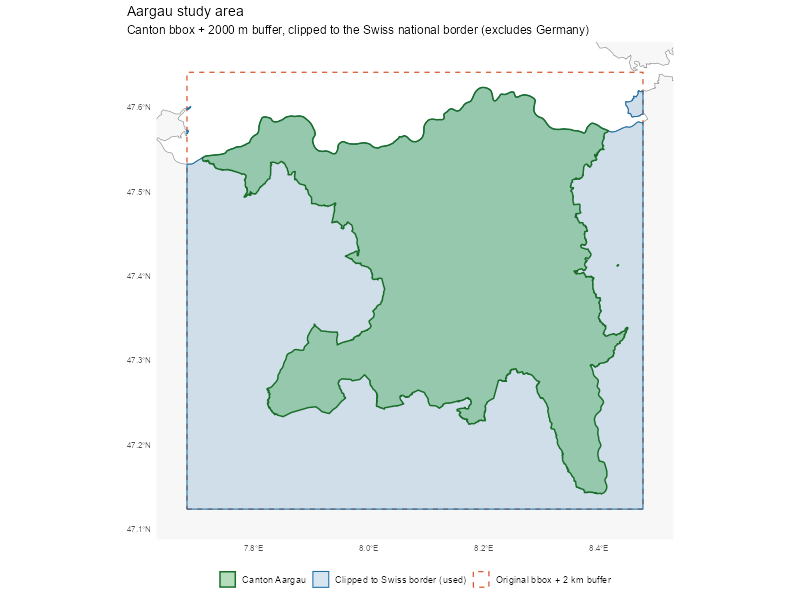

  Saved: ../docs/presentation/images/aargau_study_area.png


In [46]:
# --- Visualise the Aargau study area ---------------------------------------
# Shows the original buffered bbox, the Swiss-border-clipped extent that is
# actually used, and the canton itself, on top of the Swiss country outline.

PLOT_OUT <- "../docs/presentation/images/aargau_study_area.png"

# Wrap sfc objects in sf so they can carry a fill aesthetic for the legend
bbox_layer   <- st_as_sf(aargau_bbox_rect)
clip_layer   <- st_as_sf(aargau_bbox_buffered)
canton_layer <- aargau_poly

p_area <- ggplot() +
  # Country outline for context
  geom_sf(data = swiss_poly,
          fill = "grey97", colour = "grey55", linewidth = 0.3) +
  # Original (unclipped) bbox - dashed orange outline only
  geom_sf(data = bbox_layer,
          aes(fill = "Original bbox + 2 km buffer"),
          colour = "#D85A30", linetype = "dashed", linewidth = 0.6,
          alpha = 0) +
  # Clipped extent used by every raster
  geom_sf(data = clip_layer,
          aes(fill = "Clipped to Swiss border (used)"),
          colour = "#1D6FA5", linewidth = 0.5, alpha = 0.18) +
  # Canton itself
  geom_sf(data = canton_layer,
          aes(fill = "Canton Aargau"),
          colour = "#1B6E2A", linewidth = 0.7, alpha = 0.35) +
  scale_fill_manual(
    name   = NULL,
    values = c(
      "Original bbox + 2 km buffer"    = "white",
      "Clipped to Swiss border (used)" = "#1D6FA5",
      "Canton Aargau"                  = "#2A9D3F"
    ),
    guide  = guide_legend(override.aes = list(
      colour   = c("#1B6E2A", "#1D6FA5", "#D85A30"),
      linetype = c("solid",   "solid",   "dashed"),
      alpha    = c(0.35,      0.18,      0)
    ))
  ) +
  # Zoom on the Aargau region with a small margin
  coord_sf(
    xlim = c(st_bbox(bbox_layer)["xmin"] - 4000,
             st_bbox(bbox_layer)["xmax"] + 4000),
    ylim = c(st_bbox(bbox_layer)["ymin"] - 4000,
             st_bbox(bbox_layer)["ymax"] + 4000),
    crs    = 2056,
    expand = FALSE
  ) +
  labs(
    title    = "Aargau study area",
    subtitle = sprintf(
      "Canton bbox + %d m buffer, clipped to the Swiss national border (excludes Germany)",
      BUFFER_M
    ),
    x = NULL, y = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title.position = "plot",
    legend.position     = "bottom",
    panel.grid          = element_blank(),
    axis.text           = element_text(size = 8)
  )

print(p_area)

ggsave(PLOT_OUT, p_area, width = 8, height = 7, dpi = 200, bg = "white")
cat(sprintf("  Saved: %s\n", PLOT_OUT))

In [30]:
cat("── 4b. Forest cover, density & edge distance ──\n")

# Helper: rasterize a vector layer with touches = TRUE (critical for narrow features)
stamp <- function(r, sf_obj, val = 1) {
  if (!is.null(sf_obj) && nrow(sf_obj) > 0)
    rasterize(vect(sf_obj), r, field = val, update = TRUE, touches = TRUE)
  else r
}

# Load land cover once - reused for forest below, clipped to the rectangle
bodenbedeckung <- st_read(TLM_PATH, layer = "tlm_bb_bodenbedeckung",
                          wkt_filter = aargau_wkt, quiet = TRUE)

# --- Forest binary ----------------------------------------------------------
forest_sf <- bodenbedeckung %>% filter(objektart %in% FOREST_CLASSES)
r_forest  <- rasterize(vect(forest_sf), master_grid,
                       field = 1, background = 0, touches = TRUE)
r_forest  <- mask(r_forest, aargau_bbox_vect)
names(r_forest) <- "forest"

# --- Forest density: proportion of forest within a 50 m radius --------------
cat("  Calculating 50 m forest density...\n")

# Build a Boolean focal mask (1 = inside circle, NA = outside), so that
# focal(mean) returns the exact proportion of forest within the disk.
fw <- focalMat(r_forest, 50, "circle")
fw[fw > 0]  <- 1
fw[fw == 0] <- NA

r_forest_dens <- focal(r_forest, w = fw, fun = "mean", na.rm = TRUE)
r_forest_dens <- mask(r_forest_dens, aargau_bbox_vect)
names(r_forest_dens) <- "forest_density"

# --- True (signed) distance to the forest edge -----------------------------
# Outside forest: distance to the nearest forest pixel.
# Inside forest:  distance to the nearest non-forest pixel (= depth into forest).
# Both are positive, so the layer is an unsigned distance-to-edge raster.
cat("  Calculating distance to forest edge...\n")
dist_outside <- distance(ifel(r_forest == 1, 1, NA))
dist_inside  <- distance(ifel(r_forest == 0, 1, NA))
r_dist_forest <- ifel(r_forest == 1, dist_inside, dist_outside)
r_dist_forest <- mask(r_dist_forest, aargau_bbox_vect)
names(r_dist_forest) <- "dist_forest_edge"

# --- Save outputs -----------------------------------------------------------
writeRaster(r_forest,      file.path(TEMP_DIR, "forest.tif"),           overwrite = TRUE)
writeRaster(r_forest_dens, file.path(TEMP_DIR, "forest_density.tif"),   overwrite = TRUE)
writeRaster(r_dist_forest, file.path(TEMP_DIR, "dist_forest_edge.tif"), overwrite = TRUE)

cat("  Forest layers saved.\n")


── 4b. Forest cover, density & edge distance ──


Warning message:
In geom[[1]][[1]] == c(2, 2) :
  longer object length is not a multiple of shorter object length


  Calculating 50 m forest density...
  Calculating distance to forest edge...
  Forest layers saved.


In [31]:
cat("── 4c. Terrain: slope and TRI from DHM25 ──\n")

# 1. DHM25 has no embedded CRS - assign LV03 manually
dem_raw      <- rast(DEM_PATH)
crs(dem_raw) <- DEM_CRS # Assumes DEM_CRS is set to "EPSG:21781"

# 2. Transform the buffered bounding box to LV03 to crop the raw data efficiently
buffer_lv03 <- st_transform(aargau_bbox_buffered, 21781)
dem_cropped <- crop(dem_raw, ext(vect(buffer_lv03)))

# Compute metrics on the raw, unsmoothed elevation data
cat("  Calculating slope and TRI on native resolution...\n")
slope_raw <- terrain(dem_cropped, v = "slope", unit = "degrees")
tri_raw   <- terrain(dem_cropped, v = "TRI")

# 4. Project the calculated metrics to the LV95 master grid
# Bilinear is the correct method here because slope and TRI are continuous variables
cat("  Reprojecting to LV95 master grid...\n")
r_slope <- project(slope_raw, master_grid, method = "bilinear")
r_tri   <- project(tri_raw,   master_grid, method = "bilinear")

# 5. Mask the final rasters to the strict Swiss-clipped study area
r_slope <- mask(r_slope, aargau_bbox_vect)
names(r_slope) <- "slope"

r_tri <- mask(r_tri, aargau_bbox_vect)
names(r_tri) <- "tri"

# 6. Save to disk
writeRaster(r_slope, file.path(TEMP_DIR, "slope.tif"), overwrite = TRUE)
writeRaster(r_tri,   file.path(TEMP_DIR, "tri.tif"),   overwrite = TRUE)

cat("  Terrain layers saved.\n")

── 4c. Terrain: slope and TRI from DHM25 ──
  Calculating slope and TRI on native resolution...
  Reprojecting to LV95 master grid...
  Terrain layers saved.


In [32]:
cat("── 4d. Distance to water ──\n")

stehendes_gewaesser <- st_read(TLM_PATH, layer = "tlm_gewaesser_stehendes_gewaesser",
                               wkt_filter = aargau_wkt, quiet = TRUE)
fliessgewaesser     <- st_read(TLM_PATH, layer = "tlm_gewaesser_fliessgewaesser",
                               wkt_filter = aargau_wkt, quiet = TRUE)

# Binary water mask: NA outside water, 1 on water pixels
r_water_bin <- rast(master_grid); r_water_bin[] <- NA

# --- Helper: convert TLM3D water-body line segments into solid polygons ----
# TLM3D distributes lake shorelines as line strings grouped by gwl_nr.
# We union the segments per water body, line-merge, then cast to POLYGON.
# Casting to MULTILINESTRING first is necessary because st_union() may
# return LINESTRING for single-segment groups, which st_line_merge() rejects.
make_solid_polys <- function(lines_sf) {
  if (is.null(lines_sf) || nrow(lines_sf) == 0) return(NULL)

  fused <- lines_sf %>%
    group_by(gwl_nr) %>%
    summarise(geometry = st_union(geom), .groups = "drop")

  fused  <- suppressWarnings(st_cast(fused, "MULTILINESTRING"))
  merged <- st_line_merge(fused)

  polys       <- suppressWarnings(st_cast(merged, "POLYGON"))
  polys_valid <- st_make_valid(polys)
  st_collection_extract(polys_valid, "POLYGON")
}

# --- 1. Standing water (lakes & islands) -----------------------------------
if (nrow(stehendes_gewaesser) > 0) {
  stehend_2d    <- st_zm(stehendes_gewaesser, drop = TRUE, what = "ZM")
  lakes_lines   <- stehend_2d %>% filter(objektart == "See")
  islands_lines <- stehend_2d %>% filter(objektart == "Seeinsel")

  lakes_polys   <- make_solid_polys(lakes_lines)
  islands_polys <- make_solid_polys(islands_lines)

  if (!is.null(lakes_polys) && nrow(lakes_polys) > 0) {
    final_water_polys <- lakes_polys
    # Punch islands out of lakes if both exist
    if (!is.null(islands_polys) && nrow(islands_polys) > 0) {
      final_water_polys <- st_difference(lakes_polys, st_union(islands_polys))
    }
    r_water_bin <- rasterize(vect(final_water_polys), r_water_bin,
                             field = 1, update = TRUE)
  }
}

# --- 2. Flowing water (ecological filter) ----------------------------------
if (nrow(fliessgewaesser) > 0) {
  fliess_2d       <- st_zm(fliessgewaesser, drop = TRUE, what = "ZM")
  fliess_filtered <- fliess_2d %>%
    filter(
      objektart == "Fliessgewaesser",                       # real rivers only
      verlauf   %in% c("Oberirdisch", "Brücke", "Wasserfall")  # exclude pipes
    )
  if (nrow(fliess_filtered) > 0) {
    r_water_bin <- rasterize(vect(st_geometry(fliess_filtered)), r_water_bin,
                             field = 1, update = TRUE, touches = TRUE)
  }
}

# --- 3. Distance to nearest water pixel -----------------------------------
cat("  Calculating distance to water...\n")
r_dist_water <- distance(r_water_bin)
r_dist_water <- mask(r_dist_water, aargau_bbox_vect)
names(r_dist_water) <- "dist_water"

writeRaster(r_dist_water, file.path(TEMP_DIR, "dist_water.tif"), overwrite = TRUE)
cat("  Water distance layer saved.\n")


── 4d. Distance to water ──


Warning message:
attribute variables are assumed to be spatially constant throughout all geometries 


  Calculating distance to water...
  Water distance layer saved.


In [33]:
cat("── 4e. Infrastructure, roads, settlements & wildlife passages ──\n")

# --- Helpers ----------------------------------------------------------------
# Drop 3D vertices and filter underground features.
# Primary: STUFE < 0 (numeric coded value from TLM3D spec).
# Secondary: KUNSTBAUTE in the configured underground list.
prep_above_ground <- function(sf_obj) {
  if (is.null(sf_obj) || nrow(sf_obj) == 0) return(sf_obj)
  x <- sf::st_zm(sf_obj, drop = TRUE, what = "ZM")
  if ("stufe" %in% names(x)) {
    s <- suppressWarnings(as.numeric(as.character(x$stufe)))
    x <- x[is.na(s) | s >= 0, , drop = FALSE]
  }
  if ("kunstbaute" %in% names(x)) {
    x <- x[is.na(x$kunstbaute) | !(x$kunstbaute %in% KUNSTBAUTE_UNDERGROUND), ,
           drop = FALSE]
  }
  x
}

# Drop disused / specialty railways that aren't real boar barriers.
clean_railways <- function(sf_obj) {
  if (is.null(sf_obj) || nrow(sf_obj) == 0) return(sf_obj)
  if ("ausser_betrieb" %in% names(sf_obj)) {
    sf_obj <- sf_obj[is.na(sf_obj$ausser_betrieb) | sf_obj$ausser_betrieb != "Wahr", ,
                     drop = FALSE]
  }
  for (flag in c("standseilbahn", "zahnradbahn", "museumsbahn")) {
    if (flag %in% names(sf_obj)) {
      sf_obj <- sf_obj[is.na(sf_obj[[flag]]) | sf_obj[[flag]] != "Wahr", ,
                       drop = FALSE]
    }
  }
  sf_obj
}

# --- Load vector layers (3D dropped, underground filtered) ------------------
strassen <- prep_above_ground(
  st_read(TLM_PATH, layer = "tlm_strassen_strasse",
          wkt_filter = aargau_wkt, quiet = TRUE)
)

eisenbahn <- tryCatch(
  clean_railways(prep_above_ground(
    st_read(TLM_PATH, layer = "tlm_oev_eisenbahn",
            wkt_filter = aargau_wkt, quiet = TRUE)
  )),
  error = function(e) NULL
)

# Settlement polygons from tlm_namen_siedlungsname
siedlung_sf <- tryCatch(
  st_read(TLM_PATH, layer = SETTLEMENT_LAYER,
          wkt_filter = aargau_wkt, quiet = TRUE) %>%
    st_zm(drop = TRUE, what = "ZM") %>%
    filter(objektart %in% SETTLEMENT_CLASSES),
  error = function(e) { message("  Note: settlement layer not loaded."); NULL }
)
cat(sprintf("  Settlement polygons : %d\n",
            if (is.null(siedlung_sf)) 0 else nrow(siedlung_sf)))

# --- Split roads by class ---------------------------------------------------
fenced_roads <- strassen %>% filter(objektart %in% FENCED_ROAD_CLASSES)
main_roads   <- strassen %>% filter(objektart %in% MAINROAD_CLASSES)
sec_roads    <- strassen %>% filter(objektart %in% SECONDARY_ROAD_CLASSES)

cat(sprintf("  After filtering: fenced=%d | main=%d | secondary=%d | rail=%d\n",
            nrow(fenced_roads), nrow(main_roads), nrow(sec_roads),
            if (is.null(eisenbahn)) 0 else nrow(eisenbahn)))

# --- 1. Fenced (highway) roads ---------------------------------------------
r_fenced_bin  <- rast(master_grid); r_fenced_bin[] <- NA
r_fenced_bin  <- stamp(r_fenced_bin, fenced_roads)
r_dist_fenced <- mask(distance(r_fenced_bin), aargau_bbox_vect)
names(r_dist_fenced) <- "dist_fenced_road"

# --- 2. Main roads ----------------------------------------------------------
r_main_bin  <- rast(master_grid); r_main_bin[] <- NA
r_main_bin  <- stamp(r_main_bin, main_roads)
r_dist_main <- mask(distance(r_main_bin), aargau_bbox_vect)
names(r_dist_main) <- "dist_main_road"

# --- 3. Secondary roads -----------------------------------------------------
# Used as a graded iSSF covariate only - NOT burned in as an absolute barrier
# because boar routinely cross 2-4 m forest tracks.
r_sec_bin  <- rast(master_grid); r_sec_bin[] <- NA
r_sec_bin  <- stamp(r_sec_bin, sec_roads)
r_dist_sec <- mask(distance(r_sec_bin), aargau_bbox_vect)
names(r_dist_sec) <- "dist_secondary_road"

# --- 4. Settlements (built-up polygons, NOT individual buildings) ----------
r_settle_bin <- rast(master_grid); r_settle_bin[] <- NA
if (!is.null(siedlung_sf) && nrow(siedlung_sf) > 0) {
  r_settle_bin <- rasterize(vect(st_make_valid(siedlung_sf)), r_settle_bin,
                            field = 1, update = TRUE, touches = TRUE)
  cat("  Using tlm_namen_siedlungsname polygons.\n")
} else {
  cat("  WARNING: no settlement polygons found.\n")
}
r_dist_settle <- mask(distance(r_settle_bin), aargau_bbox_vect)
names(r_dist_settle) <- "dist_settlement"

# --- 5. Railways ------------------------------------------------------------
r_rail_bin  <- rast(master_grid); r_rail_bin[] <- NA
r_rail_bin  <- stamp(r_rail_bin, eisenbahn)
r_dist_rail <- mask(distance(r_rail_bin), aargau_bbox_vect)
names(r_dist_rail) <- "dist_railway"

# --- Combined infrastructure mask (Step 6 absolute-barrier burn-in) --------
# Secondary roads are intentionally excluded - they are not absolute
# barriers, only graded covariates in the iSSF.
r_infra <- rast(master_grid); r_infra[] <- NA
r_infra <- stamp(r_infra, fenced_roads)
r_infra <- stamp(r_infra, main_roads)
r_infra <- stamp(r_infra, eisenbahn)
if (!is.null(siedlung_sf) && nrow(siedlung_sf) > 0) {
  r_infra <- rasterize(vect(st_make_valid(siedlung_sf)), r_infra,
                       field = 1, update = TRUE, touches = TRUE)
}

# --- Highway binary (absolute barrier) -------------------------------------
r_highway <- rast(master_grid); r_highway[] <- 0
r_highway <- stamp(r_highway, fenced_roads)
r_highway <- mask(r_highway, aargau_bbox_vect)
names(r_highway) <- "highway"

# --- Wildlife passages ------------------------------------------------------
passages_sf <- tryCatch(
  st_read(PASSAGES_GDB, layer = PASSAGES_LAYER, quiet = TRUE) %>%
    st_zm(drop = TRUE, what = "ZM") %>%
    st_transform(2056) %>%
    st_filter(aargau_bbox_buffered),
  error = function(e) { message("  Note: passages layer not loaded."); NULL }
)
r_passages <- rast(master_grid); r_passages[] <- 0
if (!is.null(passages_sf) && nrow(passages_sf) > 0) {
  r_passages <- stamp(r_passages, st_buffer(passages_sf, dist = 30))
}
names(r_passages) <- "passages"

# --- Save -------------------------------------------------------------------
writeRaster(r_dist_fenced, file.path(TEMP_DIR, "dist_fenced_road.tif"),    overwrite = TRUE)
writeRaster(r_dist_main,   file.path(TEMP_DIR, "dist_main_road.tif"),      overwrite = TRUE)
writeRaster(r_dist_sec,    file.path(TEMP_DIR, "dist_secondary_road.tif"), overwrite = TRUE)
writeRaster(r_dist_settle, file.path(TEMP_DIR, "dist_settlement.tif"),     overwrite = TRUE)
writeRaster(r_dist_rail,   file.path(TEMP_DIR, "dist_railway.tif"),        overwrite = TRUE)
writeRaster(r_highway,     file.path(TEMP_DIR, "highway.tif"),             overwrite = TRUE)
writeRaster(r_passages,    file.path(TEMP_DIR, "passages.tif"),            overwrite = TRUE)
cat("  Infrastructure and passage layers saved.\n")


── 4e. Infrastructure, roads, settlements & wildlife passages ──
  Settlement polygons : 6624
  After filtering: fenced=1629 | main=25012 | secondary=262468 | rail=8474
  Using tlm_namen_siedlungsname polygons.
  Infrastructure and passage layers saved.


In [34]:
cat("── 4f. Assemble covariate stack ──\n")

cov_stack <- c(r_forest, r_forest_dens, r_dist_forest,
               r_slope, r_tri, r_dist_water,
               r_dist_fenced, r_dist_main, r_dist_sec,
               r_dist_settle, r_dist_rail)
names(cov_stack) <- c("forest", "forest_density", "dist_forest_edge",
                      "slope", "tri", "dist_water",
                      "dist_fenced_road", "dist_main_road", "dist_secondary_road",
                      "dist_settlement", "dist_railway")

writeRaster(cov_stack, file.path(TEMP_DIR, "covariate_stack.tif"), overwrite = TRUE)

cat(sprintf("  Stack: %d layers @ %d m resolution\n",
            nlyr(cov_stack), TARGET_RES_M))
print(names(cov_stack))

── 4f. Assemble covariate stack ──
  Stack: 11 layers @ 25 m resolution
 [1] "forest"              "forest_density"      "dist_forest_edge"   
 [4] "slope"               "tri"                 "dist_water"         
 [7] "dist_fenced_road"    "dist_main_road"      "dist_secondary_road"
[10] "dist_settlement"     "dist_railway"       


## Step 5 — Integrated Step-Selection Function (iSSF)

Fit a conditional logistic regression on **in-matrix steps only**, comparing
each observed step to 10 random alternatives drawn from the empirical
step-length and turning-angle distributions.

Covariates are z-standardised so β coefficients are directly comparable.
- **Positive β** → habitat preferred during transit → lower resistance
- **Negative β** → habitat avoided during transit → higher resistance

The scaling parameters (mean, SD per covariate) are saved — they are used
again in Steps 6 and 7 to ensure Zürich rasters are scaled identically
to the Aargau training data.

In [35]:
cat("── 5. Fitting iSSF on in-matrix steps ──\n")

# --- 1. Prepare clean in-matrix steps ----------------------------------------
in_matrix_clean <- in_matrix %>%
  filter(!is.na(sl_), !is.na(ta_), sl_ > 0)

class(in_matrix_clean) <- c("steps_xyt", "steps_xy", "data.frame")
cat(sprintf("  In-matrix steps: %d\n", nrow(in_matrix_clean)))

# --- 2. Generate random control steps ----------------------------------------
issf_data <- in_matrix_clean %>%
  random_steps(n_control = N_RANDOM_STEPS) %>%
  mutate(
    log_sl = log(sl_ + 1),   # Movement kernel term
    cos_ta = cos(ta_)        # Directional persistence term
  )

# --- 3. Extract covariate values at step endpoints ---------------------------
cat("  Extracting covariates at step endpoints...\n")

# 1. Check your raw coordinates to determine their native format
is_lv03 <- mean(issf_data$x2_, na.rm = TRUE) < 1000000

# 2. Assign the CORRECT native CRS based on the coordinate numbers
native_crs <- ifelse(is_lv03, "EPSG:21781", "EPSG:2056")
cat(sprintf("  Detected native point CRS as: %s\n", native_crs))

# 3. Create the spatial points object with the native CRS
pts <- terra::vect(issf_data, geom = c("x2_", "y2_"), crs = native_crs)

# 4. CRITICAL FIX: Mathematically project the points to exactly match the raster
pts_projected <- terra::project(pts, terra::crs(cov_stack))

# 5. Extract the values using the newly aligned points
ext_val <- terra::extract(cov_stack, pts_projected)

# 6. Bind to the dataframe and drop NoData rows (steps outside Canton Aargau)
issf_data <- cbind(issf_data, ext_val[, -1])
issf_data <- issf_data %>%
  filter(complete.cases(across(all_of(names(cov_stack)))))

cat(sprintf("  Valid steps after extraction: %d\n", nrow(issf_data)))
if (nrow(issf_data) == 0) stop("No valid steps. The extents still do not overlap.")

# --- 4. Identify and z-standardise valid covariates --------------------------
# Continuous covariates (exclude binary forest — handled as factor)
continuous_covs <- c("forest_density", "dist_forest_edge",
                     "slope", "tri", "dist_water",
                     "dist_fenced_road", "dist_main_road", "dist_secondary_road",
                     "dist_settlement", "dist_railway")
available_covs  <- intersect(continuous_covs, names(issf_data))

# Drop covariates with zero variance (constant raster or no data)
valid_covs <- Filter(function(cov) {
  s <- sd(issf_data[[cov]], na.rm = TRUE)
  if (is.na(s) || s == 0) {
    cat(sprintf("  WARNING: '%s' dropped (zero variance)\n", cov))
    FALSE
  } else TRUE
}, available_covs)

# Save scaling parameters — MUST be reused for prediction rasters in Steps 6 & 7
scale_params <- issf_data %>%
  summarise(across(all_of(valid_covs),
                   list(mean = ~ mean(.x, na.rm = TRUE),
                        sd   = ~ sd(.x,   na.rm = TRUE))))

# Z-standardise
issf_data <- issf_data %>%
  mutate(across(all_of(valid_covs),
                ~ (.x - mean(.x, na.rm = TRUE)) / sd(.x, na.rm = TRUE),
                .names = "{.col}_sc"))

issf_data$forest_fct <- as.factor(issf_data$forest)

# --- 5. Build model formula dynamically --------------------------------------
scaled_covs <- paste0(valid_covs, "_sc")
frm <- as.formula(paste(
  "case_ ~",
  paste(c("forest_fct", "log_sl", "cos_ta", scaled_covs, "strata(step_id_)"),
        collapse = " + ")
))
cat("  Formula:\n"); print(frm)

# Final NA drop
issf_model_data <- issf_data %>%
  drop_na(all_of(c("case_", "forest_fct", "log_sl", "cos_ta", scaled_covs)))
cat(sprintf("  Rows used in model: %d\n", nrow(issf_model_data)))
if (nrow(issf_model_data) == 0) stop("No rows remaining after NA drop.")

# --- 6. Fit conditional logistic regression ----------------------------------
cat("  Fitting clogit...\n")
m_issf <- survival::clogit(frm, data = issf_model_data, method = "efron")
cat("  Model fitted successfully.\n")
print(summary(m_issf))

# --- 7. Save coefficients and plot -------------------------------------------
coef_df <- broom::tidy(m_issf, conf.int = TRUE) %>%
  filter(!grepl("log_sl|cos_ta|step_id", term)) %>%
  arrange(desc(abs(estimate)))

write.csv(coef_df, file.path(OUT_DIR, "issf_coefficients.csv"), row.names = FALSE)

p_coef <- ggplot(coef_df,
                 aes(x = estimate, y = reorder(term, estimate),
                     xmin = conf.low, xmax = conf.high)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey60") +
  geom_pointrange(colour = "#1D6FA5", size = 0.7, linewidth = 0.9) +
  labs(x = "Selection coefficient β (positive = preferred during transit)",
       y = NULL,
       title = "iSSF — Wild Boar In-Matrix Habitat Selection",
       subtitle = "Canton Aargau | In-matrix steps only") +
  theme_minimal(base_size = 11)

ggsave(file.path(OUT_DIR, "issf_coefficients.png"), p_coef,
       width = 8, height = 5, dpi = 200, bg = "white")
cat("  Saved: issf_coefficients.csv and issf_coefficients.png\n")

── 5. Fitting iSSF on in-matrix steps ──
  In-matrix steps: 7755
  Extracting covariates at step endpoints...
  Detected native point CRS as: EPSG:21781
  Valid steps after extraction: 85064
  Formula:
case_ ~ forest_fct + log_sl + cos_ta + forest_density_sc + dist_forest_edge_sc + 
    slope_sc + tri_sc + dist_water_sc + dist_fenced_road_sc + 
    dist_main_road_sc + dist_secondary_road_sc + dist_settlement_sc + 
    dist_railway_sc + strata(step_id_)
  Rows used in model: 85064
  Fitting clogit...
  Model fitted successfully.
Call:
coxph(formula = Surv(rep(1, 85064L), case_) ~ forest_fct + log_sl + 
    cos_ta + forest_density_sc + dist_forest_edge_sc + slope_sc + 
    tri_sc + dist_water_sc + dist_fenced_road_sc + dist_main_road_sc + 
    dist_secondary_road_sc + dist_settlement_sc + dist_railway_sc + 
    strata(step_id_), data = issf_model_data, method = "efron")

  n= 85064, number of events= 7754 

                           coef exp(coef) se(coef)      z Pr(>|z|)    
forest_fct

## Step 6 — Resistance Surface for Aargau (Keeley et al. 2016)

Three-stage conversion from iSSF coefficients to a resistance raster:

1. **Linear predictor** η = Σ β̂ₖ · xₖˢᶜᵃˡᵉᵈ  
2. **Habitat suitability** S = (η − η_min) / (η_max − η_min) ∈ [0, 1]  
3. **Resistance** R = exp(C × (1 − S)), C = 4 → R ∈ [1, 54.6]

Absolute barriers (highways, open water, direct infrastructure pixels) are
burned in at R_max. Wildlife passages are burned in at R_min.

In [36]:
cat("── 6. Building Aargau resistance raster ──\n")

beta  <- coef(m_issf)
R_max <- exp(KEELEY_C)   # ~= 54.6
R_min <- 1

# --- Helpers ----------------------------------------------------------------
get_beta <- function(name) {
  b <- beta[name]
  if (is.null(b) || is.na(b)) 0 else as.numeric(b)
}
scale_raster <- function(r, varname) {
  mn <- as.numeric(scale_params[[paste0(varname, "_mean")]])
  sd <- as.numeric(scale_params[[paste0(varname, "_sd")]])
  (r - mn) / sd
}

# --- 1. Scale rasters using Aargau training parameters ---------------------
r_forest_dens_sc      <- scale_raster(r_forest_dens, "forest_density")
r_dist_forest_edge_sc <- scale_raster(r_dist_forest, "dist_forest_edge")
r_dist_water_sc       <- scale_raster(r_dist_water,  "dist_water")
r_dist_fenced_sc      <- scale_raster(r_dist_fenced, "dist_fenced_road")
r_dist_main_sc        <- scale_raster(r_dist_main,   "dist_main_road")
r_dist_sec_sc         <- scale_raster(r_dist_sec,    "dist_secondary_road")
r_dist_settle_sc      <- scale_raster(r_dist_settle, "dist_settlement")
r_dist_rail_sc        <- scale_raster(r_dist_rail,   "dist_railway")

# --- 2. Linear predictor (eta) ---------------------------------------------
eta <- (r_forest_dens_sc      * get_beta("forest_density_sc"))      +
       (r_dist_forest_edge_sc * get_beta("dist_forest_edge_sc"))    +
       (r_dist_water_sc       * get_beta("dist_water_sc"))          +
       (r_dist_fenced_sc      * get_beta("dist_fenced_road_sc"))    +
       (r_dist_main_sc        * get_beta("dist_main_road_sc"))      +
       (r_dist_sec_sc         * get_beta("dist_secondary_road_sc")) +
       (r_dist_settle_sc      * get_beta("dist_settlement_sc"))     +
       (r_dist_rail_sc        * get_beta("dist_railway_sc"))

# Store eta range - reused in Step 7 for Zürich normalisation
eta_min <- global(eta, "min", na.rm = TRUE)[[1]]
eta_max <- global(eta, "max", na.rm = TRUE)[[1]]

# --- 3. Habitat suitability S in [0, 1] ------------------------------------
S <- (eta - eta_min) / (eta_max - eta_min)

# --- 4. Keeley exponential transformation ----------------------------------
R <- exp(KEELEY_C * (1 - S))

# --- 5. Burn in absolute barriers and passages -----------------------------
# r_infra excludes secondary roads (see cell 18). Order matters only in
# that passages must come last so they override any overlapping barrier.
R[r_highway == 1]                          <- R_max         # Motorways
R[!is.na(r_water_bin) & r_water_bin == 1]  <- R_max * 0.9   # Open water
R[r_infra == 1]                            <- R_max         # Main roads + rail + settlements
R[r_passages == 1]                         <- R_min         # Wildlife passages

# --- 6. Mask to the buffered rectangle and save ----------------------------
S <- mask(S, aargau_bbox_vect); names(S) <- "habitat_suitability"
R <- mask(R, aargau_bbox_vect); names(R) <- "resistance"

writeRaster(S, file.path(OUT_DIR, "Habitat_Suitability_Wildboar_Aargau.tif"),    overwrite = TRUE)
writeRaster(R, file.path(OUT_DIR, "Resistance_Keeley_Wildboar_Aargau_25m.tif"), overwrite = TRUE)

cat(sprintf("  Resistance range: [%.2f, %.2f]\n",
            global(R, "min", na.rm = TRUE)[[1]],
            global(R, "max", na.rm = TRUE)[[1]]))
cat("  Aargau resistance rasters saved.\n")


── 6. Building Aargau resistance raster ──
  Resistance range: [1.00, 54.60]
  Aargau resistance rasters saved.


## Step 7 — Transfer Resistance Surface to Canton Zürich

Rebuild identical covariate layers for Zürich, then apply the Aargau model:

**The golden rule:** Zürich rasters are scaled using **Aargau's** means and
standard deviations (from `scale_params`), and normalised using **Aargau's**
η range (`eta_min`, `eta_max`). This ensures the resistance values are
behaviourally calibrated and that the two cantons form a seamless surface.

**Zürich-specific addition:** Permanent ASP fences (`Dauerzäune.shp` from
the Cantonal Veterinary Office) are burned in as absolute barriers. Wild boar
cannot pass through woven-wire ASP fencing — unlike deer, which can jump most
agricultural fences.

In [37]:
cat("── 7a. Zürich boundary & master grid ──\n")

zurich_poly <- kantone %>% filter(name == "Zürich")
zurich_vect <- vect(zurich_poly)

# Buffered rectangle around Canton Zürich (same procedure as Aargau)
bbox_zh <- st_bbox(zurich_poly)
bbox_zh["xmin"] <- bbox_zh["xmin"] - BUFFER_M
bbox_zh["ymin"] <- bbox_zh["ymin"] - BUFFER_M
bbox_zh["xmax"] <- bbox_zh["xmax"] + BUFFER_M
bbox_zh["ymax"] <- bbox_zh["ymax"] + BUFFER_M

# Create the perfect rectangle first
zurich_bbox_rect <- st_as_sfc(bbox_zh)

# Chop off the German part of the rectangle
zurich_bbox_buffered <- st_intersection(zurich_bbox_rect, swiss_poly)

# Generate vectorized and wkt version
zurich_bbox_vect     <- vect(zurich_bbox_buffered)
zurich_wkt           <- st_as_text(st_geometry(zurich_bbox_buffered))

master_grid_zh <- rast(ext(zurich_bbox_vect),
                       resolution = TARGET_RES_M, crs = "EPSG:2056")

cat(sprintf("  Zürich master grid: %d rows x %d cols\n",
            nrow(master_grid_zh), ncol(master_grid_zh)))


── 7a. Zürich boundary & master grid ──
  Zürich master grid: 2538 rows x 2066 cols


In [38]:
cat("── 7b. Zürich covariate layers ──\n")

# --- Forest cover, density & edge distance (Zürich) -------------------------
bodenbedeckung_zh <- st_read(TLM_PATH, layer = "tlm_bb_bodenbedeckung",
                             wkt_filter = zurich_wkt, quiet = TRUE)

forest_sf_zh <- bodenbedeckung_zh %>% filter(objektart %in% FOREST_CLASSES)
r_forest_zh  <- rasterize(vect(forest_sf_zh), master_grid_zh,
                          field = 1, background = 0, touches = TRUE)
r_forest_zh  <- mask(r_forest_zh, zurich_bbox_vect)
names(r_forest_zh) <- "forest"

cat("  Calculating 50 m forest density (ZH)...\n")
fw_zh <- focalMat(r_forest_zh, 50, "circle")
fw_zh[fw_zh > 0]  <- 1
fw_zh[fw_zh == 0] <- NA

r_forest_dens_zh <- focal(r_forest_zh, w = fw_zh, fun = "mean", na.rm = TRUE)
r_forest_dens_zh <- mask(r_forest_dens_zh, zurich_bbox_vect)
names(r_forest_dens_zh) <- "forest_density"

cat("  Calculating distance to forest edge (ZH)...\n")
dist_outside_zh  <- distance(ifel(r_forest_zh == 1, 1, NA))
dist_inside_zh   <- distance(ifel(r_forest_zh == 0, 1, NA))
r_dist_forest_zh <- ifel(r_forest_zh == 1, dist_inside_zh, dist_outside_zh)
r_dist_forest_zh <- mask(r_dist_forest_zh, zurich_bbox_vect)
names(r_dist_forest_zh) <- "dist_forest_edge"

# --- Water (standing + flowing, using the helper defined in cell 17) -------
stehendes_gewaesser_zh <- st_read(TLM_PATH, layer = "tlm_gewaesser_stehendes_gewaesser",
                                  wkt_filter = zurich_wkt, quiet = TRUE)
fliessgewaesser_zh     <- st_read(TLM_PATH, layer = "tlm_gewaesser_fliessgewaesser",
                                  wkt_filter = zurich_wkt, quiet = TRUE)

r_water_bin_zh <- rast(master_grid_zh); r_water_bin_zh[] <- NA

if (nrow(stehendes_gewaesser_zh) > 0) {
  stehend_2d_zh    <- st_zm(stehendes_gewaesser_zh, drop = TRUE, what = "ZM")
  lakes_lines_zh   <- stehend_2d_zh %>% filter(objektart == "See")
  islands_lines_zh <- stehend_2d_zh %>% filter(objektart == "Seeinsel")

  lakes_polys_zh   <- make_solid_polys(lakes_lines_zh)
  islands_polys_zh <- make_solid_polys(islands_lines_zh)

  if (!is.null(lakes_polys_zh) && nrow(lakes_polys_zh) > 0) {
    final_water_polys_zh <- lakes_polys_zh
    if (!is.null(islands_polys_zh) && nrow(islands_polys_zh) > 0) {
      final_water_polys_zh <- st_difference(lakes_polys_zh,
                                            st_union(islands_polys_zh))
    }
    r_water_bin_zh <- rasterize(vect(final_water_polys_zh), r_water_bin_zh,
                                field = 1, update = TRUE)
  }
}

if (nrow(fliessgewaesser_zh) > 0) {
  fliess_2d_zh       <- st_zm(fliessgewaesser_zh, drop = TRUE, what = "ZM")
  fliess_filtered_zh <- fliess_2d_zh %>%
    filter(
      objektart == "Fliessgewaesser",
      verlauf   %in% c("Oberirdisch", "Brücke", "Wasserfall")
    )
  if (nrow(fliess_filtered_zh) > 0) {
    r_water_bin_zh <- rasterize(vect(st_geometry(fliess_filtered_zh)),
                                r_water_bin_zh,
                                field = 1, update = TRUE, touches = TRUE)
  }
}

cat("  Calculating distance to water (ZH)...\n")
r_dist_water_zh <- distance(r_water_bin_zh)
r_dist_water_zh <- mask(r_dist_water_zh, zurich_bbox_vect)
names(r_dist_water_zh) <- "dist_water"

# --- Infrastructure (spec-compliant, 3D dropped, underground filtered) -----
strassen_zh <- prep_above_ground(
  st_read(TLM_PATH, layer = "tlm_strassen_strasse",
          wkt_filter = zurich_wkt, quiet = TRUE)
)

eisenbahn_zh <- tryCatch(
  clean_railways(prep_above_ground(
    st_read(TLM_PATH, layer = "tlm_oev_eisenbahn",
            wkt_filter = zurich_wkt, quiet = TRUE)
  )),
  error = function(e) NULL
)

siedlung_sf_zh <- tryCatch(
  st_read(TLM_PATH, layer = SETTLEMENT_LAYER,
          wkt_filter = zurich_wkt, quiet = TRUE) %>%
    st_zm(drop = TRUE, what = "ZM") %>%
    filter(objektart %in% SETTLEMENT_CLASSES),
  error = function(e) { message("  Note: settlement layer not loaded for Zürich."); NULL }
)

fenced_roads_zh <- strassen_zh %>% filter(objektart %in% FENCED_ROAD_CLASSES)
main_roads_zh   <- strassen_zh %>% filter(objektart %in% MAINROAD_CLASSES)
sec_roads_zh    <- strassen_zh %>% filter(objektart %in% SECONDARY_ROAD_CLASSES)

cat(sprintf("  Zürich after filtering: fenced=%d | main=%d | secondary=%d | rail=%d\n",
            nrow(fenced_roads_zh), nrow(main_roads_zh), nrow(sec_roads_zh),
            if (is.null(eisenbahn_zh)) 0 else nrow(eisenbahn_zh)))

# --- Per-class distance rasters --------------------------------------------
r_fenced_bin_zh  <- rast(master_grid_zh); r_fenced_bin_zh[] <- NA
r_fenced_bin_zh  <- stamp(r_fenced_bin_zh, fenced_roads_zh)
r_dist_fenced_zh <- mask(distance(r_fenced_bin_zh), zurich_bbox_vect)
names(r_dist_fenced_zh) <- "dist_fenced_road"

r_main_bin_zh  <- rast(master_grid_zh); r_main_bin_zh[] <- NA
r_main_bin_zh  <- stamp(r_main_bin_zh, main_roads_zh)
r_dist_main_zh <- mask(distance(r_main_bin_zh), zurich_bbox_vect)
names(r_dist_main_zh) <- "dist_main_road"

r_sec_bin_zh  <- rast(master_grid_zh); r_sec_bin_zh[] <- NA
r_sec_bin_zh  <- stamp(r_sec_bin_zh, sec_roads_zh)
r_dist_sec_zh <- mask(distance(r_sec_bin_zh), zurich_bbox_vect)
names(r_dist_sec_zh) <- "dist_secondary_road"

r_settle_bin_zh <- rast(master_grid_zh); r_settle_bin_zh[] <- NA
if (!is.null(siedlung_sf_zh) && nrow(siedlung_sf_zh) > 0) {
  r_settle_bin_zh <- rasterize(vect(st_make_valid(siedlung_sf_zh)),
                               r_settle_bin_zh,
                               field = 1, update = TRUE, touches = TRUE)
  cat("  Using tlm_namen_siedlungsname polygons (Zürich).\n")
} else {
  cat("  WARNING: no settlement polygons found for Zürich.\n")
}
r_dist_settle_zh <- mask(distance(r_settle_bin_zh), zurich_bbox_vect)
names(r_dist_settle_zh) <- "dist_settlement"

r_rail_bin_zh  <- rast(master_grid_zh); r_rail_bin_zh[] <- NA
r_rail_bin_zh  <- stamp(r_rail_bin_zh, eisenbahn_zh)
r_dist_rail_zh <- mask(distance(r_rail_bin_zh), zurich_bbox_vect)
names(r_dist_rail_zh) <- "dist_railway"

# --- Combined infrastructure mask (absolute-barrier burn-in in Step 7c) ----
# Secondary roads are intentionally excluded - mirrors the Aargau logic.
r_infra_zh <- rast(master_grid_zh); r_infra_zh[] <- NA
r_infra_zh <- stamp(r_infra_zh, fenced_roads_zh)
r_infra_zh <- stamp(r_infra_zh, main_roads_zh)
r_infra_zh <- stamp(r_infra_zh, eisenbahn_zh)
if (!is.null(siedlung_sf_zh) && nrow(siedlung_sf_zh) > 0) {
  r_infra_zh <- rasterize(vect(st_make_valid(siedlung_sf_zh)), r_infra_zh,
                          field = 1, update = TRUE, touches = TRUE)
}

# --- Highway binary (absolute barrier) -------------------------------------
r_highway_zh <- rast(master_grid_zh); r_highway_zh[] <- 0
r_highway_zh <- stamp(r_highway_zh, fenced_roads_zh)
r_highway_zh <- mask(r_highway_zh, zurich_bbox_vect)
names(r_highway_zh) <- "highway"

# --- Wildlife passages ------------------------------------------------------
passages_sf_zh <- tryCatch(
  st_read(PASSAGES_GDB, layer = PASSAGES_LAYER, quiet = TRUE) %>%
    st_zm(drop = TRUE, what = "ZM") %>%
    st_transform(2056) %>%
    st_filter(zurich_bbox_buffered),
  error = function(e) { message("  Note: passages layer not loaded."); NULL }
)
r_passages_zh <- rast(master_grid_zh); r_passages_zh[] <- 0
if (!is.null(passages_sf_zh) && nrow(passages_sf_zh) > 0) {
  r_passages_zh <- stamp(r_passages_zh, st_buffer(passages_sf_zh, dist = 30))
}
names(r_passages_zh) <- "passages"

# --- Permanent fences (Zürich-specific absolute barrier) -------------------
fences_sf_zh <- tryCatch(
  st_read(FENCE_PATH, quiet = TRUE) %>%
    st_zm(drop = TRUE, what = "ZM") %>%
    st_transform(2056) %>%
    st_filter(zurich_bbox_buffered),
  error = function(e) { message("  Note: fence layer not loaded."); NULL }
)
r_fences_zh <- rast(master_grid_zh); r_fences_zh[] <- NA
if (!is.null(fences_sf_zh) && nrow(fences_sf_zh) > 0) {
  r_fences_zh <- rasterize(vect(fences_sf_zh), r_fences_zh,
                           field = 1, update = TRUE, touches = TRUE)
}
r_fences_zh <- mask(r_fences_zh, zurich_bbox_vect)
names(r_fences_zh) <- "fences"

# --- Save all Zurich layers to data/temp with _zurich suffix ---------------
writeRaster(r_forest_zh,      file.path(TEMP_DIR, "forest_zurich.tif"),              overwrite = TRUE)
writeRaster(r_forest_dens_zh, file.path(TEMP_DIR, "forest_density_zurich.tif"),      overwrite = TRUE)
writeRaster(r_dist_forest_zh, file.path(TEMP_DIR, "dist_forest_edge_zurich.tif"),    overwrite = TRUE)
writeRaster(r_dist_water_zh,  file.path(TEMP_DIR, "dist_water_zurich.tif"),          overwrite = TRUE)
writeRaster(r_dist_fenced_zh, file.path(TEMP_DIR, "dist_fenced_road_zurich.tif"),    overwrite = TRUE)
writeRaster(r_dist_main_zh,   file.path(TEMP_DIR, "dist_main_road_zurich.tif"),      overwrite = TRUE)
writeRaster(r_dist_sec_zh,    file.path(TEMP_DIR, "dist_secondary_road_zurich.tif"), overwrite = TRUE)
writeRaster(r_dist_settle_zh, file.path(TEMP_DIR, "dist_settlement_zurich.tif"),     overwrite = TRUE)
writeRaster(r_dist_rail_zh,   file.path(TEMP_DIR, "dist_railway_zurich.tif"),        overwrite = TRUE)
writeRaster(r_highway_zh,     file.path(TEMP_DIR, "highway_zurich.tif"),             overwrite = TRUE)
writeRaster(r_passages_zh,    file.path(TEMP_DIR, "passages_zurich.tif"),            overwrite = TRUE)
writeRaster(r_fences_zh,      file.path(TEMP_DIR, "fences_zurich.tif"),              overwrite = TRUE)

cat("  Zürich covariate layers ready and saved to data/temp.\n")


── 7b. Zürich covariate layers ──


Warning message:
In geom[[1]][[1]] == c(2, 2) :
  longer object length is not a multiple of shorter object length


  Calculating 50 m forest density (ZH)...
  Calculating distance to forest edge (ZH)...


Warning messages:
1: In st_collection_extract.sf(polys_valid, "POLYGON") :
  x is already of type POLYGON.
2: attribute variables are assumed to be spatially constant throughout all geometries 


  Calculating distance to water (ZH)...
  Zürich after filtering: fenced=2092 | main=35460 | secondary=274564 | rail=9905
  Using tlm_namen_siedlungsname polygons (Zürich).
  Zürich covariate layers ready and saved to data/temp.


In [39]:
cat("── 7c. Apply Aargau model to Zürich ──\n")

# Scale Zürich rasters using Aargau's training mean/sd (NOT Zürich's own)
scale_raster_zh <- function(r_zh, varname) {
  mn <- as.numeric(scale_params[[paste0(varname, "_mean")]])
  sd <- as.numeric(scale_params[[paste0(varname, "_sd")]])
  (r_zh - mn) / sd
}

r_forest_dens_sc_zh      <- scale_raster_zh(r_forest_dens_zh, "forest_density")
r_dist_forest_edge_sc_zh <- scale_raster_zh(r_dist_forest_zh, "dist_forest_edge")
r_dist_water_sc_zh       <- scale_raster_zh(r_dist_water_zh,  "dist_water")
r_dist_fenced_sc_zh      <- scale_raster_zh(r_dist_fenced_zh, "dist_fenced_road")
r_dist_main_sc_zh        <- scale_raster_zh(r_dist_main_zh,   "dist_main_road")
r_dist_sec_sc_zh         <- scale_raster_zh(r_dist_sec_zh,    "dist_secondary_road")
r_dist_settle_sc_zh      <- scale_raster_zh(r_dist_settle_zh, "dist_settlement")
r_dist_rail_sc_zh        <- scale_raster_zh(r_dist_rail_zh,   "dist_railway")

# Linear predictor with Aargau coefficients
eta_zh <- (r_forest_dens_sc_zh      * get_beta("forest_density_sc"))      +
          (r_dist_forest_edge_sc_zh * get_beta("dist_forest_edge_sc"))    +
          (r_dist_water_sc_zh       * get_beta("dist_water_sc"))          +
          (r_dist_fenced_sc_zh      * get_beta("dist_fenced_road_sc"))    +
          (r_dist_main_sc_zh        * get_beta("dist_main_road_sc"))      +
          (r_dist_sec_sc_zh         * get_beta("dist_secondary_road_sc")) +
          (r_dist_settle_sc_zh      * get_beta("dist_settlement_sc"))     +
          (r_dist_rail_sc_zh        * get_beta("dist_railway_sc"))

# Normalise using Aargau's eta range - ensures a seamless cross-canton surface
S_zh <- (eta_zh - eta_min) / (eta_max - eta_min)
S_zh <- clamp(S_zh, lower = 0, upper = 1)

# Keeley transformation
R_zh <- exp(KEELEY_C * (1 - S_zh))

# Burn-in absolute barriers (passages last so they override roads).
# r_infra_zh excludes secondary roads (see cell 26).
R_zh[r_highway_zh == 1]                            <- R_max
R_zh[!is.na(r_water_bin_zh) & r_water_bin_zh == 1] <- R_max * 0.9
R_zh[r_infra_zh == 1]                              <- R_max
R_zh[!is.na(r_fences_zh) & r_fences_zh == 1]       <- R_max   # Zürich ASP fences
R_zh[r_passages_zh == 1]                           <- R_min

# Mask to the buffered rectangle and save
S_zh <- mask(S_zh, zurich_bbox_vect); names(S_zh) <- "habitat_suitability_zurich"
R_zh <- mask(R_zh, zurich_bbox_vect); names(R_zh) <- "resistance_zurich"

writeRaster(S_zh, file.path(OUT_DIR, "Habitat_Suitability_Wildboar_Zurich_25m.tif"), overwrite = TRUE)
writeRaster(R_zh, file.path(OUT_DIR, "Resistance_Keeley_Wildboar_Zurich_25m.tif"),  overwrite = TRUE)

cat(sprintf("  Zürich resistance range: [%.2f, %.2f]\n",
            global(R_zh, "min", na.rm = TRUE)[[1]],
            global(R_zh, "max", na.rm = TRUE)[[1]]))
cat("── Pipeline complete. ──\n")


── 7c. Apply Aargau model to Zürich ──
  Zürich resistance range: [1.00, 54.60]
── Pipeline complete. ──


## Step 8 — Diagnostic Plots & Output Summary

── 8. Diagnostic plots ──


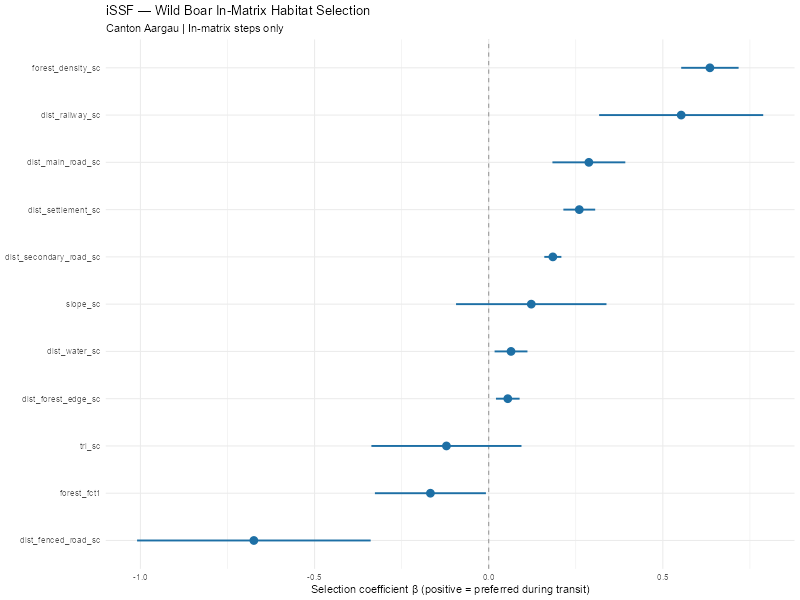


  PIPELINE COMPLETE

  [OK     ] WildBoar_InPatch_Steps.csv
  [OK     ] WildBoar_InMatrix_Steps.csv
  [OK     ] issf_coefficients.csv
  [OK     ] issf_coefficients.png
  [OK     ] suitability_resistance_maps_Aargau.png
  [OK     ] suitability_resistance_maps_Zurich.png
  [OK     ] resistance_histogram.png
  [OK     ] Habitat_Suitability_Wildboar_Aargau.tif
  [OK     ] Resistance_Keeley_Wildboar_Aargau_25m.tif
  [OK     ] Habitat_Suitability_Wildboar_Zurich_25m.tif
  [OK     ] Resistance_Keeley_Wildboar_Zurich_25m.tif


In [40]:
cat("── 8. Diagnostic plots ──\n")

# --- iSSF coefficient forest plot (already saved - display inline) ---------
print(p_coef)

# --- Suitability and resistance maps side-by-side --------------------------
png(file.path(OUT_DIR, "suitability_resistance_maps_Aargau.png"),
    width = 2400, height = 1100, res = 200)
par(mfrow = c(1, 2))
plot(S, main = "Habitat Suitability (0-1)\nHigh = preferred during transit",
     col = hcl.colors(50, "Greens 3"), axes = FALSE)
plot(R, main = "Resistance (Keeley C=4)\nLow = permeable",
     col = rev(hcl.colors(50, "Inferno")), axes = FALSE)
dev.off()

png(file.path(OUT_DIR, "suitability_resistance_maps_Zurich.png"),
    width = 2400, height = 1100, res = 200)
par(mfrow = c(1, 2))
plot(S_zh, main = "Habitat Suitability Zürich (0-1)",
     col = hcl.colors(50, "Greens 3"), axes = FALSE)
plot(R_zh, main = "Resistance Zürich (Keeley C=4)",
     col = rev(hcl.colors(50, "Inferno")), axes = FALSE)
dev.off()

# --- Resistance histogram --------------------------------------------------
png(file.path(OUT_DIR, "resistance_histogram.png"),
    width = 1400, height = 800, res = 200)
r_vals <- na.omit(as.numeric(values(R)))
hist(r_vals, breaks = 60, col = "#D85A30", border = "white",
     xlab = "Resistance value", ylab = "Pixel count",
     main = "Distribution of Resistance Values - Aargau")
abline(v = R_max, col = "black", lty = 2, lwd = 1.5)
text(R_max * 0.96, par("usr")[4] * 0.88,
     "Absolute\nbarrier", adj = 1, cex = 0.7)
dev.off()

# --- Output summary --------------------------------------------------------
cat("\n======================================================\n")
cat("  PIPELINE COMPLETE\n")
cat("======================================================\n\n")

outputs <- c(
  "WildBoar_InPatch_Steps.csv",
  "WildBoar_InMatrix_Steps.csv",
  "issf_coefficients.csv",
  "issf_coefficients.png",
  "suitability_resistance_maps_Aargau.png",
  "suitability_resistance_maps_Zurich.png",
  "resistance_histogram.png",
  "Habitat_Suitability_Wildboar_Aargau.tif",
  "Resistance_Keeley_Wildboar_Aargau_25m.tif",
  "Habitat_Suitability_Wildboar_Zurich_25m.tif",
  "Resistance_Keeley_Wildboar_Zurich_25m.tif"
)

for (f in outputs) {
  status <- if (file.exists(file.path(OUT_DIR, f))) "OK     " else "MISSING"
  cat(sprintf("  [%s] %s\n", status, f))
}
